# **Máster en Behavioral Data Science** - Instituto de Formación Continua (IL3) - Universitat de Barcelona
## **Módulo 7: Aprendizaje Automático - Reto II**
Autor: **Meysam Madadi**

Colaborador: **Julio C. S. Jacques Junior**

---

# Antes de empezar
- Cada vez que se requiera una respuesta (o fragmento de código) habrá un texto en rojo o un comentario en una celda de código, donde deberás (hacer doble clic en la celda y) proporcionar la información requerida.
- Se recomienda crear una copia de este archivo para que puedas practicar todo lo que necesites antes de entregar la tarea.
- **No cambie la estructura ni el formato** de este archivo.
- Cuando hayas terminado, puedes hacer clic en "File", "Download", **"Dowload .ipynb"**.
- Nombre el archivo descargado como "**Nombre_Apellido_Reto_2.ipynb**" antes de enviarlo.

---
# Información personal
<font color='red'>(Haga doble clic en esta celda e informe...)</font>

<font color='red'> GRUPO E -- Lluís Baldirà Jorro,
Maria Barraza Diaz,
Max Comerma i Martos,
Ana Gabriela Dos Santos Figueira</font>

---

# **Reto 2:** Técnicas de clasificación binaria supervisada para la predicción de diabetes utilizando datos tabulares.
* Debido a la presencia de una fase asintomática relativamente larga, siempre es deseable una detección temprana de la diabetes. Alrededor del 50% de las personas que sufren de diabetes no están diagnosticadas debido a su fase asintomática. El [conjunto de datos](https://https://www.kaggle.com/datasets/andrewmvd/early-diabetes-classification) utilizado en este reto contiene 520 muestras (con 17 características cada), recopiladas mediante cuestionarios directos y resultados de diagnóstico de los pacientes en el Hospital de Diabetes de Sylhet, Bangladesh.

# Descargando los datos
- Los datos descargados se pueden encontrar usando la interfaz de Colab (en la parte izquierda de esta ventana, en "Files")

In [ ]:
# descargando los datos
!wget http://data.chalearnlap.cvc.uab.cat/Colab_MFPDS/2024BehaviorDSMaster/diabetes_data.csv

--2024-06-24 18:37:13--  http://data.chalearnlap.cvc.uab.cat/Colab_MFPDS/2024BehaviorDSMaster/diabetes_data.csv
Resolving data.chalearnlap.cvc.uab.cat (data.chalearnlap.cvc.uab.cat)... 158.109.8.102
Connecting to data.chalearnlap.cvc.uab.cat (data.chalearnlap.cvc.uab.cat)|158.109.8.102|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 20859 (20K) [application/octet-stream]
Saving to: ‘diabetes_data.csv’

diabetes_data.csv   100%[===================>]  20.37K  78.6KB/s    in 0.3s    

2024-06-24 18:37:14 (78.6 KB/s) - ‘diabetes_data.csv’ saved [20859/20859]



# Visualizando los datos

Primero, carguemos y visualicemos los datos: atributos categóricos y numéricos por separado, contando el número de muestras para cada categoría o rango.

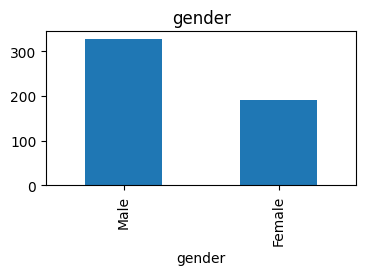

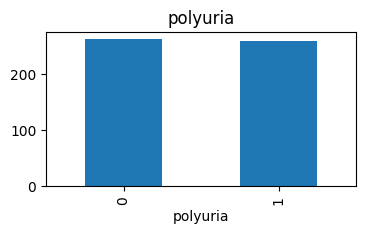

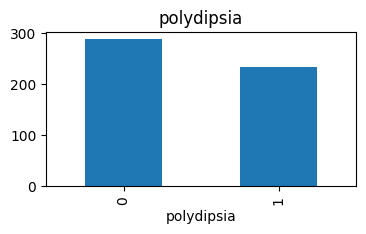

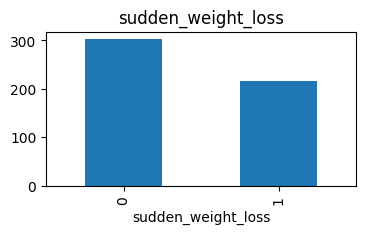

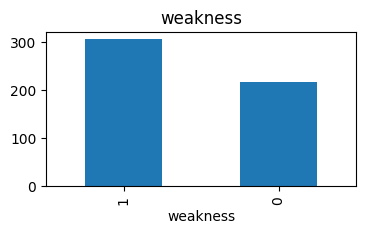

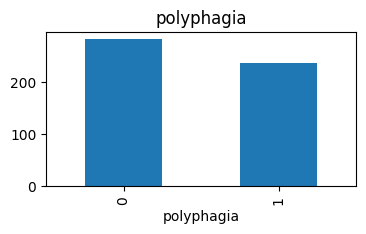

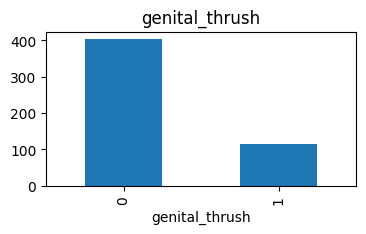

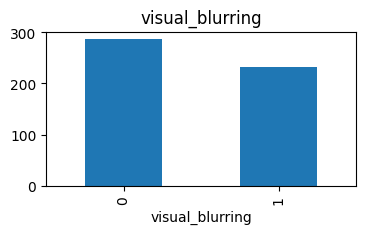

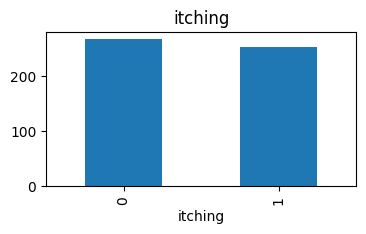

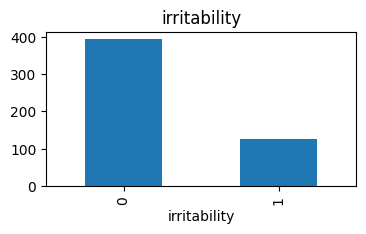

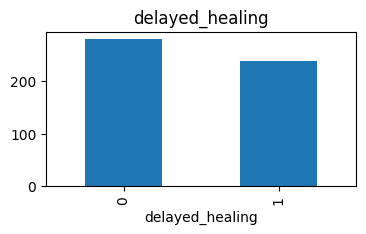

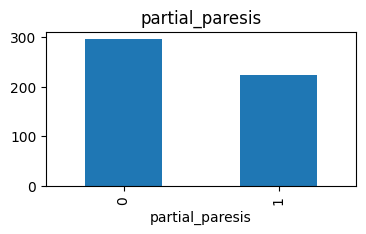

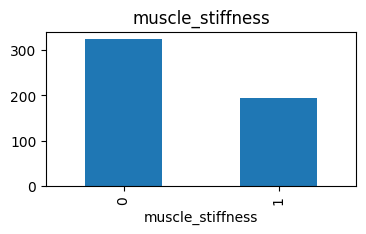

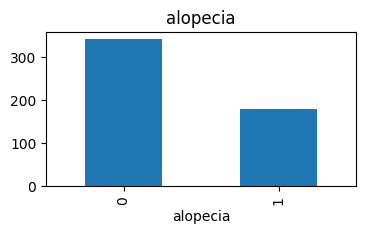

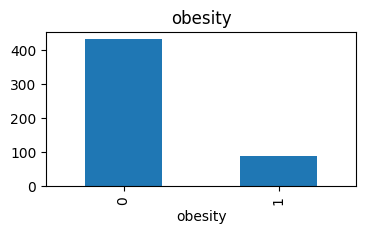

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Cargando los datos en un dataframe de pandas
df = pd.read_csv('diabetes_data.csv')

# Visualizando los atributos categóricos
for h in ['gender','polyuria','polydipsia','sudden_weight_loss','weakness','polyphagia','genital_thrush','visual_blurring','itching','irritability','delayed_healing','partial_paresis','muscle_stiffness','alopecia','obesity']:
    plt.figure(figsize=(4,2))
    df[h].value_counts().plot(kind='bar')
    plt.title(h)
    plt.show()

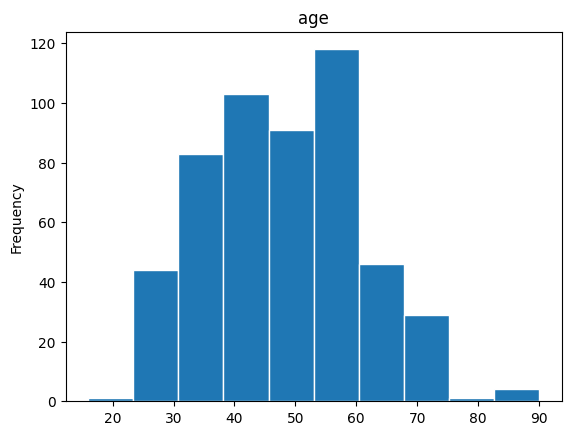

In [ ]:
# Visualizando los atributos numéricos
for h in ['age']:
    df[h].plot.hist(edgecolor="white",bins=10)
    plt.title(h)
    plt.show()

---
# **TAREA 1:** Visualizando e interpretando los datos



In [ ]:
atributos_desbalanceados = []

for h in ['gender', 'polyuria', 'polydipsia', 'sudden_weight_loss', 'weakness', 'polyphagia', 'genital_thrush', 'visual_blurring', 'itching', 'irritability', 'delayed_healing', 'partial_paresis', 'muscle_stiffness', 'alopecia', 'obesity']:
    counts = df[h].value_counts()
    percentages = (counts / counts.sum()) * 100

    if len(percentages) == 2:  # Verificar si hay exactamente dos categorías
        if (percentages.min() / percentages.max()) < 0.75:
            atributos_desbalanceados.append(h)

print("Los siguientes atributos categóricos están desbalanceados:")
for atributo in atributos_desbalanceados:
    print(atributo)


Los siguientes atributos categóricos están desbalanceados:
gender
sudden_weight_loss
weakness
genital_thrush
irritability
muscle_stiffness
alopecia
obesity


**1.A Según los gráficos generados, ¿cuáles atributos categóricos están desbalanceados, teniendo una categoría menos del 75% de muestras en comparación con la otra.** <font color='blue'> (0.5 puntos) </font>

<font color='red'> Conteste aquí (haz doble clic en la celda para activar el editor): </font>

<font color='blue'>Los siguientes atributos categóricos están desbalanceados:
gender,
sudden_weight_loss,
weakness,
genital_thrush,
irritability,
muscle_stiffness,
alopecia,
obesity


**1.B Dividiendo el atributo edad en rangos de 10 años (0-9, 10-19, 20-29, ..., 90-99), ¿qué rango de edad tiene el número máximo de casos de diabetes (atributo 'class' en la variable 'df')? Escriba la respuesta a continuación y proporcione un fragmento de código para respaldarla. Es decir, un código que cuente y muestre la cada categoría de edad que tiene más casos positivos de diabetes.** <font color='blue'> (1 punto) </font>

<font color='red'> Conteste aquí (haz doble clic en la celda para activar el editor): </font>



In [ ]:
# Dividir el atributo edad en rangos de 10 años
bins = list(range(0, 101, 10))
labels = [f'{i}-{i+9}' for i in range(0, 100, 10)]
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=False)

# Contar el número de casos positivos de diabetes en cada rango de edad
diabetes_counts = df[df['class'] == 1]['age_group'].value_counts().sort_index()

# Encontrar el rango de edad con el número máximo de casos de diabetes
max_diabetes_age_group = diabetes_counts.idxmax()
max_diabetes_cases = diabetes_counts.max()

print(f'El rango de edad con el número máximo de casos de diabetes es: {max_diabetes_age_group} con {max_diabetes_cases} casos.')

# Mostrar el conteo de casos positivos de diabetes por rango de edad
print(diabetes_counts)

El rango de edad con el número máximo de casos de diabetes es: 40-49 con 88 casos.
age_group
0-9       0
10-19     1
20-29     7
30-39    77
40-49    88
50-59    81
60-69    56
70-79     6
80-89     2
90-99     2
Name: count, dtype: int64


---
# **TAREA 2:** Preprocesamiento de datos & Generando nuestros conjuntos de entrenamiento, validación y prueba
- A continuación, practicarás cómo preparar los datos para la tarea de clasificación. Primero, convertiremos columnas categóricas en numéricas asignando cada categoría a un número único por columna. Podriamos mapearlas en vectores one-hot. Sin embargo, los atributos categóricos de este conjunto de datos son binarios, por lo que los mantendremos como 0 o 1. Finalmente, dividiremos los datos en conjuntos de entrenamiento, validación y prueba.

In [ ]:
import pandas as pd
df = pd.read_csv('diabetes_data.csv', delimiter=',', skipinitialspace=True)

# Mapeando valores no numéricos a una secuencia de enteros, en este caso (0 y 1)
df['gender'] = df['gender'].map({'Male':0, 'Female':1})

# Mostrando las primeras cinco filas. Asegúrese de que no haya valores NaN, que no son válidos.
df.head()

,age,gender,polyuria,polydipsia,sudden_weight_loss,weakness,polyphagia,genital_thrush,visual_blurring,itching,irritability,delayed_healing,partial_paresis,muscle_stiffness,alopecia,obesity,class
0,40,0,0,1,0,1,0,0,0,1,0,1,0,1,1,1,1
1,58,0,0,0,0,1,0,0,1,0,0,0,1,0,1,0,1
2,41,0,1,0,0,1,1,0,0,1,0,1,0,1,1,0,1
3,45,0,0,0,1,1,1,1,0,1,0,1,0,0,0,0,1
4,60,0,1,1,1,1,1,0,1,1,1,1,1,1,1,1,1


## Definiendo nuestros conjuntos de entrenamiento/validación/prueba

A continuación, dividimos los datos en conjuntos de entrenamiento, validación y prueba. Asignamos muestras a cada conjunto al azar con una distribución igual de clases positivas y negativas en los conjuntos de validación (100 muestras) y de prueba (100 muestras). Las etiquetas (ground truth) están representadas por el atributo "class".

**2.A En esta tarea, necesitas crear los datos de entrenamiento definidos como "X_train" y las etiquetas de entrenamiento como "y_train" con las muestras restantes. En la siguiente celda utilizamos valores aleatorios para el conjunto de entrenamiento. Debe reemplazar las dos líneas de código resaltadas para cargar el conjunto de entrenamiento correctamente.** </font> <font color='blue'> (1.5 puntos) </font>
- <font color='red'> **Importante:** Crear el conjunto de entrenamiento de manera adecuada es crucial para contestar las siguientes preguntas.



In [ ]:
import numpy as np

# Convirtiendo el pandas dataframe en un numpy array para usar en los clasificadores
X = []
for h in ['age','gender','polyuria','polydipsia','sudden_weight_loss','weakness','polyphagia','genital_thrush','visual_blurring','itching','irritability','delayed_healing','partial_paresis','muscle_stiffness','alopecia','obesity']:
  X.append(df[h].to_numpy())
X = np.array(X, np.float32).T
Y = df['class'].to_numpy()

# Normalizando los datos en el rango [0..1]
X /= X.max(axis=0, keepdims=True)

# Obteniendo índices para muestras negativas y positivas
neg_idx = np.where(Y==0)[0]
pos_idx = np.where(Y==1)[0]

# Permutar aleatoriamente las muestras
np.random.seed(7)
neg_idx = neg_idx[np.random.permutation(neg_idx.shape[0])]
pos_idx = pos_idx[np.random.permutation(pos_idx.shape[0])]

# Creando conjuntos de validación y prueba balanceados con igual número de muestras positivas y negativas
# Las características y etiquetas se mantienen en X_<set> e y_<set> respectivamente, donde <set> es "train", "val" o "test"
X_test = np.concatenate([X[neg_idx[:50]], X[pos_idx[:50]]], axis=0)
y_test = np.concatenate([Y[neg_idx[:50]], Y[pos_idx[:50]]], axis=0)

X_val = np.concatenate([X[neg_idx[50:100]], X[pos_idx[50:100]]], axis=0)
y_val = np.concatenate([Y[neg_idx[50:100]], Y[pos_idx[50:100]]], axis=0)


# =================================================
''' Escribe tu código a continuación.
    Recuerda que debes modificar las dos líneas siguientes '''
# =================================================
# X_train = np.random.rand(1000,X_val.shape[1])
# y_train = np.concatenate([np.zeros(500), np.ones(500)])


# Crear conjuntos de entrenamiento balanceados
X_train = np.concatenate([X[neg_idx[100:]], X[pos_idx[100:]]], axis=0)
y_train = np.concatenate([Y[neg_idx[100:]], Y[pos_idx[100:]]], axis=0)

print(f'Tamaño del conjunto de entrenamiento: {X_train.shape}')
print(f'Tamaño del conjunto de validación: {X_val.shape}')
print(f'Tamaño del conjunto de prueba: {X_test.shape}')




Tamaño del conjunto de entrenamiento: (320, 16)
Tamaño del conjunto de validación: (100, 16)
Tamaño del conjunto de prueba: (100, 16)


In [ ]:
X_train.size


5120

---
# **TAREA 3:** Clasificación binaria y ajuste de hiperparámetros.
- En esta tarea practicarás con una tarea de clasificación binaria, utilizando los siguientes algoritmos:
 - K Nearest Neighbor (KNN)
 - Support Vector Machine (SVM)
 - Random Forest (RF)

- Jugarás con el ajuste de hiperparámetros.
- Evaluará los resultados utilizando diferentes métricas.
- En la siguiente celda, entrenamos y evaluamos un clasificador KNN utilizando la precisión (*accuracy*) como métrica. Además, evaluamos el hiperparámetro "k" (número de vecinos).

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, average_precision_score, roc_auc_score, f1_score

scores = {0:['Train', 'Validation', 'Test']}

# Iteramos sobre los hiperparámetros utilizando un bucle y monitoreamos los resultados
# (los guardamos en "scores")
for k in range(2, 16):
    # construyendo el clasificador
    clf = KNeighborsClassifier(n_neighbors = k)

    # Entrenando al clasificador usando los datos de entrenamiento
    clf.fit(X_train, y_train)

    # Realizando la inferencia para predecir las etiquetas
    pred_train = clf.predict(X_train)
    pred_val = clf.predict(X_val)
    pred_test = clf.predict(X_test)

    # Evaluando las predicciones con respecto a las etiquetas reales
    training_score = accuracy_score(y_train, pred_train)
    val_score = accuracy_score(y_val, pred_val)
    test_score = accuracy_score(y_test, pred_test)

    # Guardando el rendimiento del hiperparámetro k
    scores[k] = [training_score, val_score, test_score]

# Imprimiendo los resultados para cada hiperparámetro
for keys, values in scores.items():
    print(keys, ':', values)

0 : ['Train', 'Validation', 'Test']
2 : [0.959375, 0.99, 0.94]
3 : [0.96875, 0.97, 0.92]
4 : [0.95, 0.96, 0.89]
5 : [0.9625, 0.96, 0.89]
6 : [0.9375, 0.93, 0.88]
7 : [0.940625, 0.94, 0.88]
8 : [0.9375, 0.94, 0.9]
9 : [0.946875, 0.94, 0.89]
10 : [0.925, 0.91, 0.89]
11 : [0.928125, 0.91, 0.88]
12 : [0.91875, 0.91, 0.89]
13 : [0.91875, 0.91, 0.89]
14 : [0.915625, 0.91, 0.89]
15 : [0.925, 0.92, 0.89]


**3.A. Basándose en los resultados de KNN, ¿cuál es el mejor hiperparámetro k? ¿Qué conjunto se debe comprobar para contestar a esta pregunta, entrenamiento, validación o prueba? Justifica tu respuesta.** <font color='blue'> (1 punto) </font>

<font color='red'> Conteste aquí (haz doble clic en la celda para activar el editor): El mejor hiperparámetro k parece ser k=2, ya que proporciona la mayor precisión en el conjunto de validación (99%). Sin embargo, debemos tener en cuenta que el rendimiento en el conjunto de prueba es un criterio crucial para evaluar el verdadero rendimiento del modelo en datos no vistos. En este caso, k=2 muestra una precisión de 94% en el conjunto de prueba, que sigue siendo bastante alto pero ligeramente menor que en el conjunto de validación.
</font>


- Los resultados de KNN evaluados en la celda anterior se evaluaron utilizando la precisión (*accuracy*) como métrica.  
- En la siguiente celda tenemos un bucle que ejecuta el entrenamiento de KNN dos veces; una vez con los datos originales y luego con ruido aleatorio agregado a los datos. Luego estudiaremos el impacto del ruido usando diferentes métricas.
- **Actualice el hiperparámetro "k" en la siguiente celda según el mejor valor que hayas definido en la pregunta anterior. Luego, ejecute la celda.**



In [ ]:
from sklearn.metrics import accuracy_score, average_precision_score, roc_auc_score, f1_score

scores = {0:['Train', 'Validation', 'Test']}

#===================================================
'''reemplace k con el mejor hiperparámetro encontrado en la tarea anterior'''
k = 4
#===================================================

# construyendo el clasificador
clf = KNeighborsClassifier(n_neighbors = k)

for i in range(2):
  train_noise = 0
  val_noise = 0
  test_noise = 0
  # Agregando ruido a los datos en la segunda iteración
  if i>0:
    np.random.seed(1)
    train_noise = 0.5-np.random.rand(X_train.shape[0], X_train.shape[1])
    val_noise = 0.5-np.random.rand(X_val.shape[0], X_val.shape[1])
    test_noise = 0.5-np.random.rand(X_test.shape[0], X_test.shape[1])

  # Entrenando al clasificador
  clf.fit(X_train+train_noise, y_train)

  # Haciendo inferencias para predecir las etiquetas
  pred_train = clf.predict(X_train+train_noise)
  pred_val = clf.predict(X_val+val_noise)
  pred_test = clf.predict(X_test+test_noise)

  # Evaluando las predicciones con respecto a las etiquetas de ground truth.
  # (usando diferentes métricas)
  for f in [accuracy_score, average_precision_score, roc_auc_score, f1_score]:
      training_score = f(y_train, pred_train)
      val_score = f(y_val, pred_val)
      test_score = f(y_test, pred_test)

      # Guardando los valores obtenidos
      scores[f.__name__] = [training_score, val_score, test_score]

  # Imprimiendo los resultados de cada métrica
  print('**** El conjunto de datos SIN ruido ****' if i==0 else '**** El conjunto de datos CON ruido ****')
  for keys, values in scores.items():
      print(keys, ':', values)
  print('')
  print('')

**** El conjunto de datos SIN ruido ****
0 : ['Train', 'Validation', 'Test']
accuracy_score : [0.95, 0.96, 0.89]
average_precision_score : [0.9741697925860546, 0.9334615384615385, 0.8640000000000001]
roc_auc_score : [0.9609090909090908, 0.96, 0.8899999999999999]
f1_score : [0.9624413145539905, 0.9607843137254902, 0.8842105263157894]


**** El conjunto de datos CON ruido ****
0 : ['Train', 'Validation', 'Test']
accuracy_score : [0.928125, 0.94, 0.87]
average_precision_score : [0.9642273869346734, 0.9061538461538462, 0.8441860465116279]
roc_auc_score : [0.945, 0.9400000000000001, 0.87]
f1_score : [0.9451073985680191, 0.9411764705882353, 0.8602150537634408]




**3.B. Teniendo en cuenta los resultados anteriores (con/sin ruido), ¿qué métrica (en este caso) parece más sensible al ruido? ¿Qué has observado para contestar esta pregunta?** <font color='blue'> (1 punto) </font>

<font color='red'>
Cambios en las métricas debido al ruido:

Accuracy Score:

Train: 0.95 - 0.928 = 0.022

Validation: 0.96 - 0.94 = 0.02

Test: 0.89 - 0.87 = 0.02


Average Precision Score:

Train: 0.974 - 0.964 = 0.01

Validation: 0.933 - 0.906 = 0.027

Test: 0.864 - 0.844 = 0.02


ROC AUC Score:

Train: 0.961 - 0.945 = 0.016

Validation: 0.96 - 0.94 = 0.02

Test: 0.89 - 0.87 = 0.02

F1 Score:

Train: 0.962 - 0.945 = 0.017

Validation: 0.961 - 0.941 = 0.02

Test: 0.884 - 0.86 = 0.024

La métrica que parece más sensible al ruido es el Average Precision Score, especialmente en el conjunto de validación, donde presenta la mayor diferencia absoluta. Observamos que esta métrica disminuyó más significativamente con la adición de ruido, indicando su mayor sensibilidad al cambio en los datos. </font>

- A continuación, entrenamos un clasificador SVM y un RF, y evaluamos algunos hiperparámetros.
 - Para el SVM, evaluamos el kernel ("lineal" y "RBF") y el término de regularización "C".
 - Para el RF, evaluamos el número de estimadores de árboles ("n_estimators") y la profundidad máxima del árbol ("max_depth").
- **Ejecute las siguientes (dos) celdas y conteste las preguntas que se muestran a continuación.**


In [ ]:
from sklearn import svm
from sklearn.metrics import f1_score as f

scores = {0:['Train', 'Validation', 'Test']}

for k in ['linear', 'rbf']:
    for reg in [0.1, 0.5, 1.0, 2.0]:

        # creando un clasificador SVM
        clf = svm.SVC(kernel=k, C=reg)

        clf.fit(X_train, y_train)

        pred_train = clf.predict(X_train)
        pred_val = clf.predict(X_val)
        pred_test = clf.predict(X_test)

        training_score = f(y_train, pred_train)
        val_score = f(y_val, pred_val)
        test_score = f(y_test, pred_test)
        scores[k+'_'+str(reg)] = [training_score, val_score, test_score]

for keys, values in scores.items():
    print(keys, ':', values)

0 : ['Train', 'Validation', 'Test']
linear_0.1 : [0.9594594594594594, 0.9056603773584904, 0.8599999999999999]
linear_0.5 : [0.9701149425287356, 0.923076923076923, 0.8599999999999999]
linear_1.0 : [0.9724770642201834, 0.923076923076923, 0.8599999999999999]
linear_2.0 : [0.9634703196347032, 0.923076923076923, 0.8599999999999999]
rbf_0.1 : [0.9508928571428571, 0.890909090909091, 0.8468468468468469]
rbf_0.5 : [0.9931972789115646, 0.9245283018867924, 0.8932038834951457]
rbf_1.0 : [0.9977324263038548, 0.9514563106796116, 0.9108910891089109]
rbf_2.0 : [0.9977324263038548, 0.9523809523809523, 0.9108910891089109]


**3.C. ¿Cuál es el "mejor" kernel cuando se usa SVM (en este caso)? ¿Tiene la regularización el mismo impacto en los dos kernels? Expande tu respuesta con una breve explicación.** <font color='blue'> (1 punto) </font>

<font color='red'> En este caso, el RBF con C 1 o 2 son los "mejores" kernel, al obtener las mejores puntuaciones, especialmente en test y validación, lo que nos sugiere que presenta un buen ajuste y una buena generalización.

La regularización es notablemente mejor en RBF al mejorar las puntuaciones F1 conforme se aumenta el valor de C, en el caso lineal no hay una mejora. Esto se debe a que el RBF transforma los datos a un espacio de alta dimensionalidad, que permite encontrar separaciones más complejas en los datos, por lo tanto, C ayudaría a mejorar el ajuste del modelo.
  </font>


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score as f

# hemos fijado la semilla para generar resultados reproducibles
np.random.seed(456)

scores = {0:['Train', 'Validation', 'Test']}

for n in [2, 5, 10]:
    for d in [5, 10, 15]:
        # creando un clasificador RF
        clf = RandomForestClassifier(n_estimators = n, max_depth=d)

        # Entrenando el modelo en el conjunto de datos de entrenamiento
        clf.fit(X_train, y_train)

        pred_train = clf.predict(X_train)
        pred_val = clf.predict(X_val)
        pred_test = clf.predict(X_test)

        training_score = f(y_train, pred_train)
        val_score = f(y_val, pred_val)
        test_score = f(y_test, pred_test)
        scores[str(n)+'_'+str(d)] = [training_score, val_score, test_score]

for keys, values in scores.items():
    print(keys, ':', values)

0 : ['Train', 'Validation', 'Test']
2_5 : [0.9750566893424037, 0.8785046728971964, 0.8686868686868686]
2_10 : [0.9931350114416476, 0.9494949494949495, 0.9148936170212766]
2_15 : [0.9791183294663574, 0.9278350515463918, 0.8510638297872342]
5_5 : [0.979214780600462, 0.94, 0.8865979381443299]
5_10 : [0.9954545454545455, 0.9411764705882353, 0.8910891089108911]
5_15 : [1.0, 0.9615384615384615, 0.9108910891089109]
10_5 : [0.9885583524027459, 0.9423076923076924, 0.9]
10_10 : [1.0, 0.9702970297029702, 0.9387755102040817]
10_15 : [0.9977220956719818, 0.9607843137254902, 0.9090909090909091]


**3.D. ¿Qué combinación de hiperparámetros es la mejor cuando se utiliza RF (en este caso)? Entre el número de estimadores de árboles y la profundidad máxima, ¿cuál parece tener más impacto en los resultados? Expande tu respuesta con una breve explicación.** <font color='blue'> (1 punto) </font>

<font color='red'> Conteste aquí (haz doble clic en la celda para activar el editor): </font>


<font color='blue'> Pareciera que conforme incrementa el número de estimadores y la profundidad máxima, los resultados tienden a mejorar. En este caso, la mejor combinación parece ser la de 10 estimadores de árboles y una profundidad máxima de 10, ya que proporciona los mejores puntajes en los conjuntos de validación y prueba. Sin embargo, es importante evaluar el posible sobreajuste, dado que el modelo alcanza un puntaje perfecto en el conjunto de entrenamiento.

<font color='blue'> Los resultados sugieren que la profundidad máxima tiene un impacto significativo en los resultados. Por ejemplo, incrementar la profundidad de 5 a 10 mejora considerablemente el rendimiento del modelo. También se observa que aumentar el número de estimadores de árboles de 2 a 5 y de 5 a 10 mejora el modelo, aunque los incrementos no son tan drásticos como los observados con la profundidad máxima.

<font color='blue'>  Lo ideal sería encontrar el equilibrio adecuado entre estos dos hiperparámetros para optimizar el rendimiento del modelo sin caer en sobreajuste. Una validación cruzada adicional y la experimentación con otros valores de estos hiperparámetros pueden ayudar a lograr este equilibrio.





---
# **TAREA 4:** Clasificación binaria utilizando una red neuronal artificial (ANN)
- A continuación, practicarás la tarea de clasificación binaria utilizando una red neuronal artificial (ANN) mientras ajusta la arquitectura, aplica regularización y la parada de entrenamiento anticipada (*early stopping*).
- En la siguiente celda tenemos una red neuronal con dos capas completamente conectadas (densas), cada una con 256 nodos y una activación "ReLU", seguidas de una capa de "dropout" con una probabilidad de eliminación de 0.2. Luego tenemos la última capa (densa) con 1 nodo (ya que tenemos un problema de clasificación binaria) y activación "sigmoid". La red se entrenará durante 20 *epochs* con el optimizador "Adam", una función de pérdida de entropía cruzada (binary_crossentropy) y un tamaño de lote (*batch size*) de 32. Además, por razones de reproducibilidad, fijamos la semilla aleatoria de Keras (*random_seed*). **Ejecute la siguiente celda y conteste las preguntas que se muestran a continuación.**

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Dense, Activation, Dropout

keras.utils.set_random_seed(800)

model = keras.Sequential()
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer=keras.optimizers.Adam(), metrics=["accuracy"])

history = model.fit(X_train, y_train, batch_size=32, epochs=20, verbose=2, validation_data=(X_val, y_val))

test_score = model.evaluate(X_test, y_test, verbose=1)[1]
print("\ntest set accuracy is ", test_score)

Epoch 1/20
10/10 - 9s - loss: 0.5505 - accuracy: 0.6656 - val_loss: 0.6206 - val_accuracy: 0.5000 - 9s/epoch - 864ms/step
Epoch 2/20
10/10 - 0s - loss: 0.3797 - accuracy: 0.7844 - val_loss: 0.4409 - val_accuracy: 0.8300 - 69ms/epoch - 7ms/step
Epoch 3/20
10/10 - 0s - loss: 0.2791 - accuracy: 0.9031 - val_loss: 0.2813 - val_accuracy: 0.9200 - 51ms/epoch - 5ms/step
Epoch 4/20
10/10 - 0s - loss: 0.2049 - accuracy: 0.9469 - val_loss: 0.2343 - val_accuracy: 0.9000 - 58ms/epoch - 6ms/step
Epoch 5/20
10/10 - 0s - loss: 0.1616 - accuracy: 0.9438 - val_loss: 0.1911 - val_accuracy: 0.9200 - 54ms/epoch - 5ms/step
Epoch 6/20
10/10 - 0s - loss: 0.1323 - accuracy: 0.9594 - val_loss: 0.1842 - val_accuracy: 0.9300 - 55ms/epoch - 6ms/step
Epoch 7/20
10/10 - 0s - loss: 0.0977 - accuracy: 0.9625 - val_loss: 0.1781 - val_accuracy: 0.9300 - 55ms/epoch - 6ms/step
Epoch 8/20
10/10 - 0s - loss: 0.0841 - accuracy: 0.9688 - val_loss: 0.1599 - val_accuracy: 0.9300 - 67ms/epoch - 7ms/step
Epoch 9/20
10/10 - 0s - 

# **4.A Según los resultados anteriores para cada *epoch*, ¿es necesario aplicar una parada de entrenamiento anticipada (*early stopping*)? En caso afirmativo, ¿en qué *epoch* el modelo podría dejar de entrenar? Justifica tu respuesta.** <font color='blue'> (0.5 puntos) </font>

<font color='red'> Conteste aquí (haz doble clic en la celda para activar el editor): </font>


<font color='blue'> Se podría aplicar una parada de entrenamiento anticipada (early stopping). Por ejemplo, podría ser en la epoch 16, ya que a partir de esta epoch la pérdida de validación deja de disminuir consistentemente como lo hacía en las epoch  anteriores. Además, la precisión de validación se estabiliza en 0.96 desde la época 12, sin mostrar mejoras significativas posteriores.


- **Edite la siguiente celda de código para evaluar los siguientes hiperparámetros:**
 - Tamaño de las dos primeras capas densas (las que tienen tamaño 256). Pruebe valores de esta lista: [32, 64, 128, 256, 512]
 - Evalúe el uso de diferentes "batch_size" en "model.fit". Pruebe valores de esta lista: [16, 32, 64, 128]
 - En el código siguiente, los mensajes de entrenamiento están ocultos porque "verbose=0".
 - Consulte el código de la Tarea 3.B (RF) para inspirarse y ejecutar todos los experimentos a la vez. Por ejemplo, utilizando dos bucles para iterar sobre los diferentes valores, entrenando diferentes modelos y evaluando los resultados. Evaluar todos estos valores requerirá altos recursos computacionales. Para ello, le recomendamos habilitar el uso de GPU en Colab (Runtime -> Change runtime type -> T4 GPU)


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Dense, Activation, Dropout

tf.random.set_seed(800)

layer_sizes1 = [32, 64, 128, 256, 512]
layer_sizes2 = [32, 64, 128, 256, 512]
batch_sizes = [16, 32, 64, 128]

for layer_size1 in layer_sizes1:
    for layer_size2 in layer_sizes2:
        for batch_size in batch_sizes:
            print(f"layer size 1 = {layer_size1}, layer size 2 = {layer_size2}, batch size = {batch_size}")

            model = keras.Sequential()
            model.add(Dense(layer_size1, activation='relu'))
            model.add(Dropout(0.2))
            model.add(Dense(layer_size2, activation='relu'))
            model.add(Dropout(0.2))
            model.add(Dense(1, activation='sigmoid'))
            model.compile(loss='binary_crossentropy', optimizer=keras.optimizers.Adam(), metrics=["accuracy"])

            history = model.fit(X_train, y_train, batch_size=batch_size, epochs=20, verbose=0, validation_data=(X_val, y_val))

            training_score = history.history['accuracy'][-1]
            val_score = history.history['val_accuracy'][-1]
            test_score = model.evaluate(X_test, y_test, verbose=0)[1]

            print(f"Training set accuracy: {training_score}")
            print(f"Validation set accuracy: {val_score}")
            print(f"Test set accuracy: {test_score}\n")



layer size 1 = 32, layer size 2 = 32, batch size = 16
Training set accuracy: 0.9593750238418579
Validation set accuracy: 0.9399999976158142
Test set accuracy: 0.8899999856948853

layer size 1 = 32, layer size 2 = 32, batch size = 32
Training set accuracy: 0.953125
Validation set accuracy: 0.9200000166893005
Test set accuracy: 0.8500000238418579

layer size 1 = 32, layer size 2 = 32, batch size = 64
Training set accuracy: 0.8218749761581421
Validation set accuracy: 0.7400000095367432
Test set accuracy: 0.6100000143051147

layer size 1 = 32, layer size 2 = 32, batch size = 128
Training set accuracy: 0.7593749761581421
Validation set accuracy: 0.5699999928474426
Test set accuracy: 0.550000011920929

layer size 1 = 32, layer size 2 = 64, batch size = 16
Training set accuracy: 0.9750000238418579
Validation set accuracy: 0.9300000071525574
Test set accuracy: 0.8700000047683716

layer size 1 = 32, layer size 2 = 64, batch size = 32
Training set accuracy: 0.965624988079071
Validation set accur

**4.B Basado en tus resultados, ¿cuál es la mejor combinación de hiperparámetros (tamaño para ambas capas y "batch size")? Justifica tu respuesta. ¿Has observado algún cambio o tendencia con respecto a la precisión evaluada en el conjunto de pruebas al aumentar el tamaño de las capas?** <font color='blue'> (2.0 puntos) </font>



<font color='red'> Consideramos que hay dos mejores combinaciones, ya que obtienen los mismos resultados, sería la de 512 capas para la primera cama, 64 para la segunda y con un batch size de 16 o 32, ya que es la que presenta valores más altos en los parámetros evaluados.
Se  observa que conforme vas aumentando el número de capas, se obtiene una mayor precisión. También es notable que, como más grande, el tamaño del batch size (64 y 28) generalmente resulta en peores resultados en comparación con los más pequeños.




 </font>


**4.C La regularización Dropout ha sido eliminada del siguiente fragmento de código. Actualízalo con los mejores hiperparámetros encontrados (en la Tarea 4.B) y explica cómo cambian los resultados en los conjuntos de validación y prueba.**
<font color='blue'> (0.5 puntos) </font>

<font color='red'> En este caso se observa una ligera disminución en el conjunto de prueba, pero en el de entrenamiento y validación se obtienen los mismos resultados. Destacar que en ambos casos la alta precisión en entrenamiento y la disminución respecto a este en la prueba podrían indicar sobreajuste, por lo tanto, sería recomendable usar el dropout.


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Dense, Activation, Dropout

keras.utils.set_random_seed(800)

model = keras.Sequential()

#===================================================
''' Cambiar el tamaño de las capas en las siguientes líneas (si es necesario) '''
model.add(Dense(512, activation='relu'))
model.add(Dense(64, activation='relu'))
#===================================================

model.add(Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer=keras.optimizers.Adam(), metrics=["accuracy"])

#===================================================
''' Cambiar el tamaño del 'batch_size' en la siguiente línea (si es necesario) '''
history = model.fit(X_train, y_train, batch_size=32, epochs=20, verbose=2, validation_data=(X_val, y_val))
#===================================================

test_score = model.evaluate(X_test, y_test, verbose=0)[1]
print("\ntest set accuracy is ", test_score)

training_score = history.history['accuracy'][-1]
val_score = history.history['val_accuracy'][-1]

print(f"Training set accuracy: {training_score}")
print(f"Validation set accuracy: {val_score}")



Epoch 1/20
10/10 - 2s - loss: 0.5702 - accuracy: 0.6594 - val_loss: 0.6138 - val_accuracy: 0.5000 - 2s/epoch - 166ms/step
Epoch 2/20
10/10 - 0s - loss: 0.4094 - accuracy: 0.7469 - val_loss: 0.5000 - val_accuracy: 0.6800 - 66ms/epoch - 7ms/step
Epoch 3/20
10/10 - 0s - loss: 0.3105 - accuracy: 0.8781 - val_loss: 0.3315 - val_accuracy: 0.8800 - 52ms/epoch - 5ms/step
Epoch 4/20
10/10 - 0s - loss: 0.2319 - accuracy: 0.9187 - val_loss: 0.2652 - val_accuracy: 0.9300 - 53ms/epoch - 5ms/step
Epoch 5/20
10/10 - 0s - loss: 0.1776 - accuracy: 0.9531 - val_loss: 0.2109 - val_accuracy: 0.9300 - 53ms/epoch - 5ms/step
Epoch 6/20
10/10 - 0s - loss: 0.1369 - accuracy: 0.9594 - val_loss: 0.1974 - val_accuracy: 0.9200 - 56ms/epoch - 6ms/step
Epoch 7/20
10/10 - 0s - loss: 0.1068 - accuracy: 0.9594 - val_loss: 0.1723 - val_accuracy: 0.9300 - 68ms/epoch - 7ms/step
Epoch 8/20
10/10 - 0s - loss: 0.0877 - accuracy: 0.9719 - val_loss: 0.1741 - val_accuracy: 0.9300 - 67ms/epoch - 7ms/step
Epoch 9/20
10/10 - 0s - 